<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [8]:
# YOUR CODE HERE
df = pd.read_csv(r"C:\Users\jojah\GA_DSB\labs_projects\labs_projects\labs\TimeSer\data\residents.csv", parse_dates=['date'], date_format='%m-%Y')
df.set_index('date', inplace=True)
df.index.freq = 'QS'

df.head()

,residents
date,
1971-04-01,13067.3
1971-07-01,13130.5
1971-10-01,13198.4
1972-01-01,13254.2
1972-04-01,13303.7


### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [9]:
# YOUR CODE HERE
df_eda = df.iloc[:-8]
holdout_df = df.iloc[-8:]

print(df_eda.shape, holdout_df.shape)
holdout_df

(81, 1) (8, 1)


,residents
date,
1991-07-01,17354.2
1991-10-01,17414.2
1992-01-01,17447.3
1992-04-01,17482.6
1992-07-01,17526.0
1992-10-01,17568.7
1993-01-01,17627.1
1993-04-01,17661.5


### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

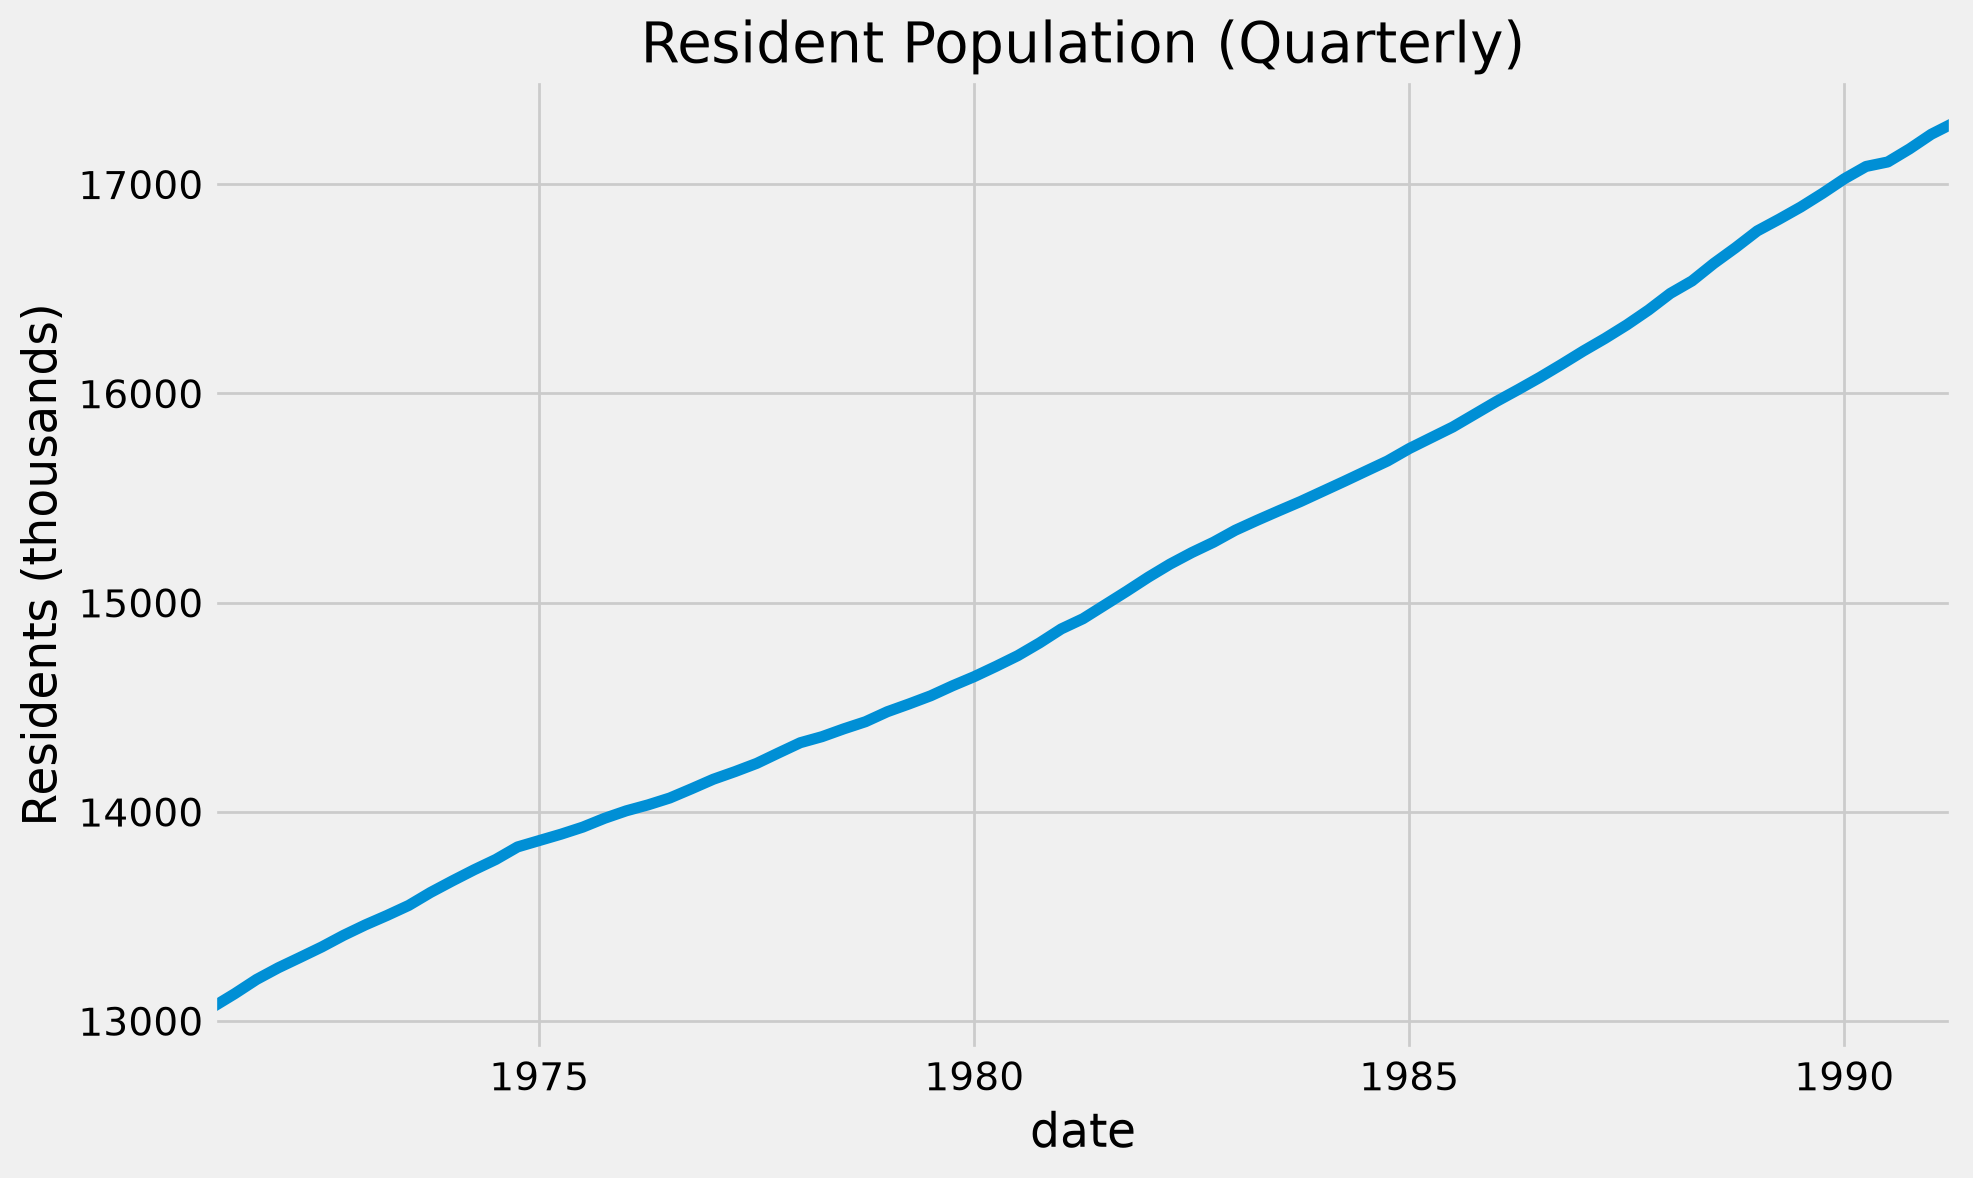

In [10]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
df_eda['residents'].plot()
plt.title('Resident Population (Quarterly)')
plt.ylabel('Residents (thousands)')
plt.show()

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

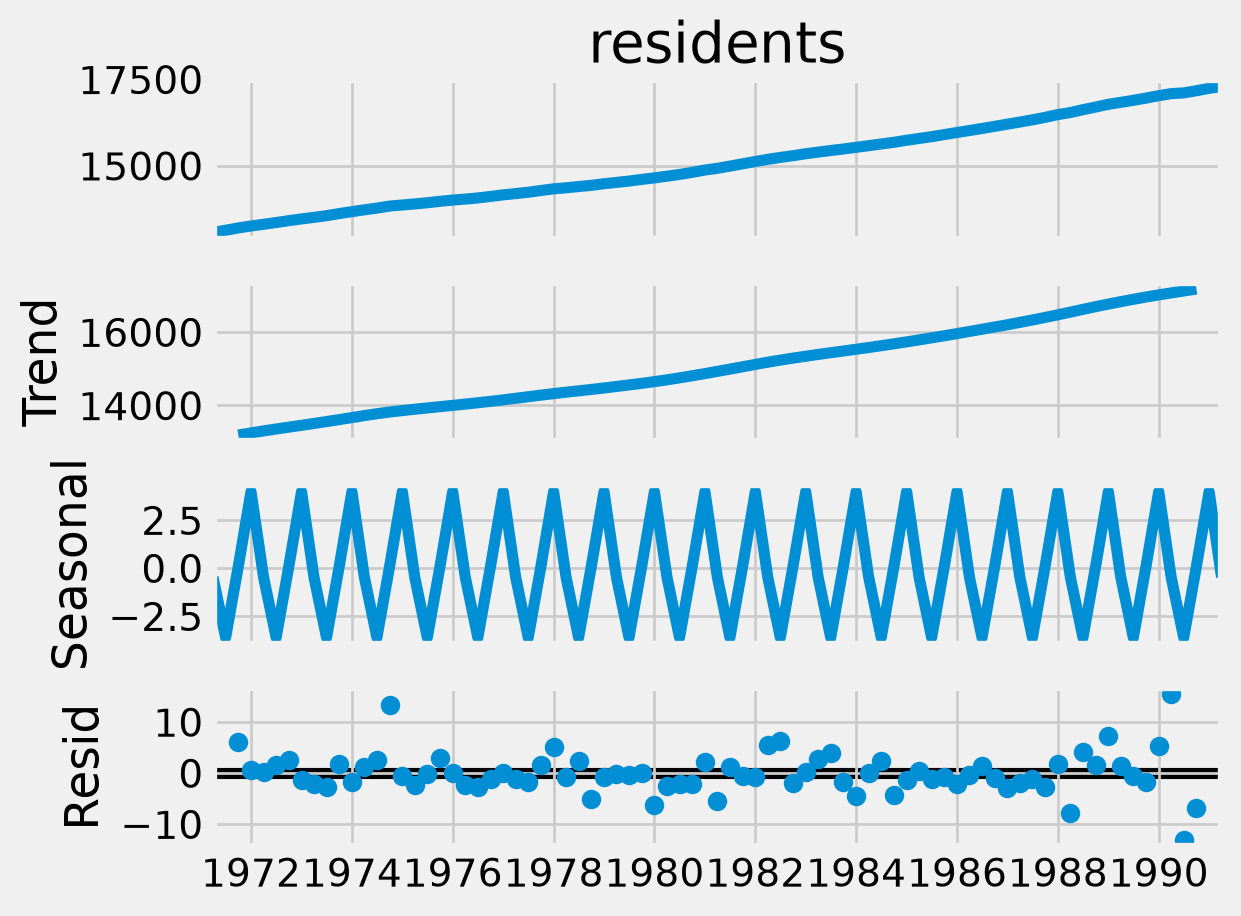

In [11]:
# YOUR CODE HERE
result = seasonal_decompose(df_eda['residents'], period=4)
result.plot()
plt.show()

## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

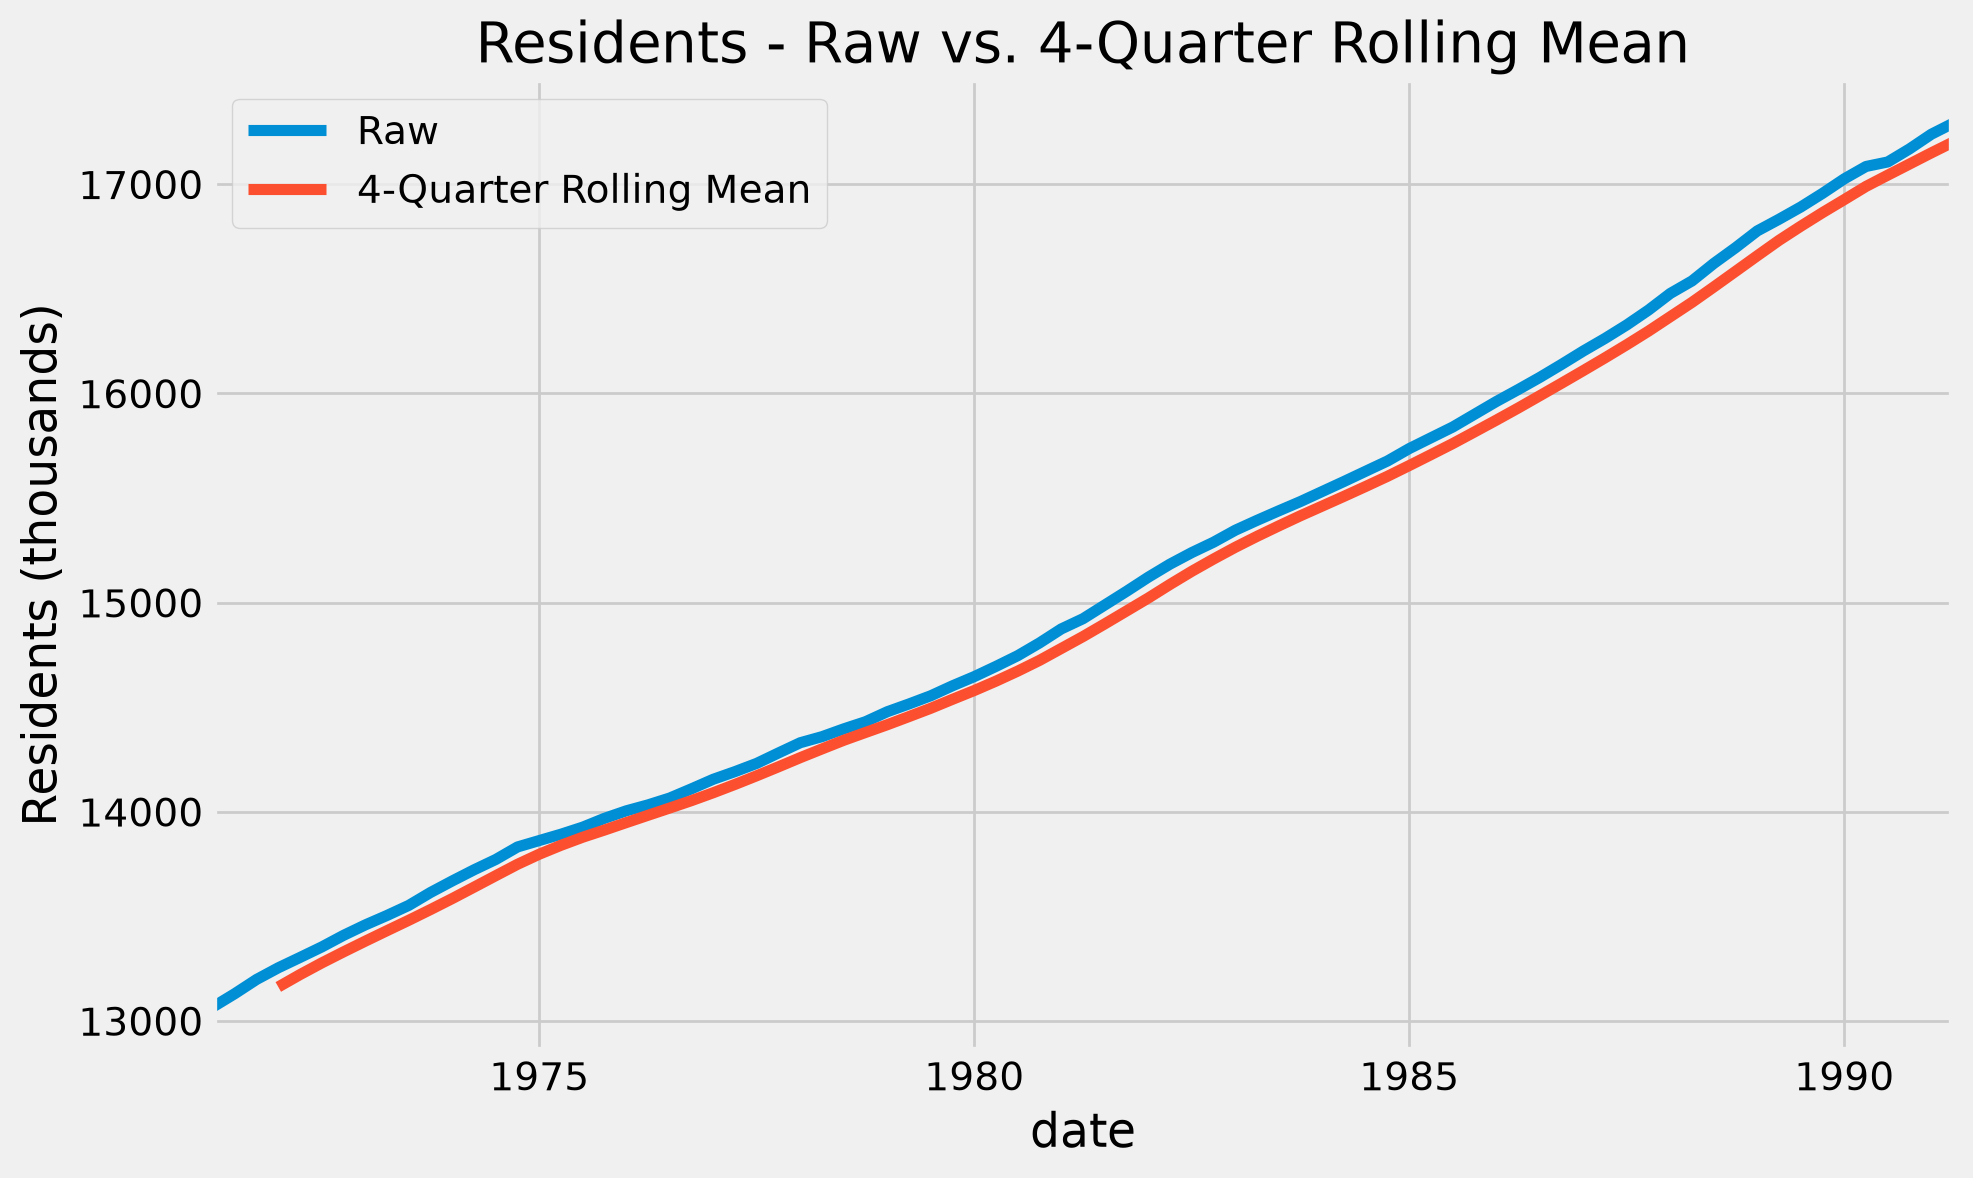

In [12]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
df_eda['residents'].plot(label='Raw')
df_eda['residents'].rolling(window=4).mean().plot(label='4-Quarter Rolling Mean')
plt.title('Residents - Raw vs. 4-Quarter Rolling Mean')
plt.ylabel('Residents (thousands)')
plt.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

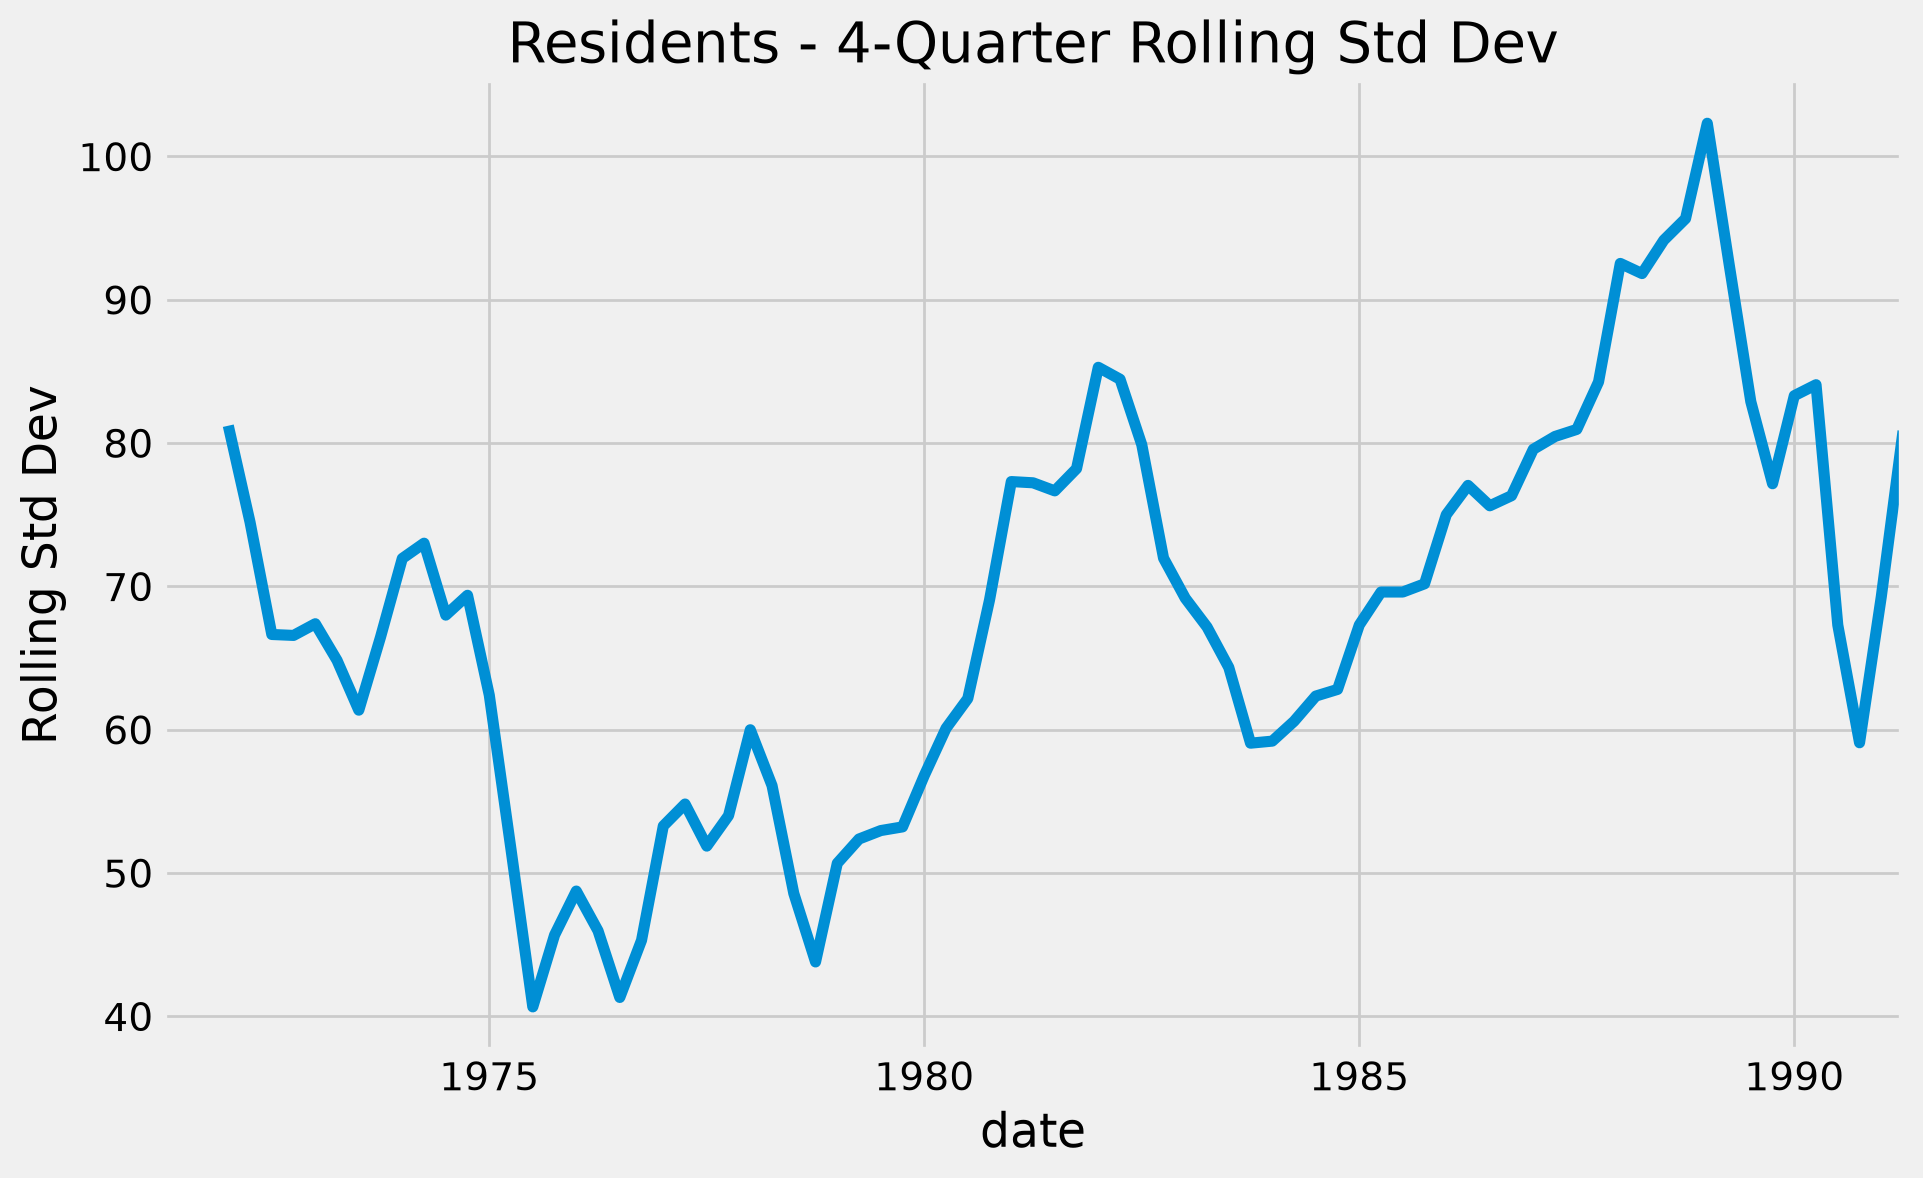

In [13]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
df_eda['residents'].rolling(window=4).std().plot()
plt.title('Residents - 4-Quarter Rolling Std Dev')
plt.ylabel('Rolling Std Dev')
plt.show()


## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [18]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [15]:
# YOUR CODE HERE
adf_test(df_eda['residents'])
print()
adf_test(df_eda['residents'].diff())

ADF test statistic       1.810417
p-value                  0.998369
# lags used              6.000000
# observations          74.000000
critical value (1%)     -3.521980
critical value (5%)     -2.901470
critical value (10%)    -2.588072
Weak evidence against null
Fail to reject the null 
Data has a unit root and is non-stationary

ADF test statistic      -2.505616
p-value                  0.114114
# lags used              5.000000
# observations          74.000000
critical value (1%)     -3.521980
critical value (5%)     -2.901470
critical value (10%)    -2.588072
Weak evidence against null
Fail to reject the null 
Data has a unit root and is non-stationary


### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [16]:
# YOUR CODE HERE
adf_test(df_eda['residents'].diff().diff())

ADF test statistic      -3.148284
p-value                  0.023180
# lags used              4.000000
# observations          74.000000
critical value (1%)     -3.521980
critical value (5%)     -2.901470
critical value (10%)    -2.588072
Strong evidence against null
Reject the null 
Data has no unit root and is stationary


## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

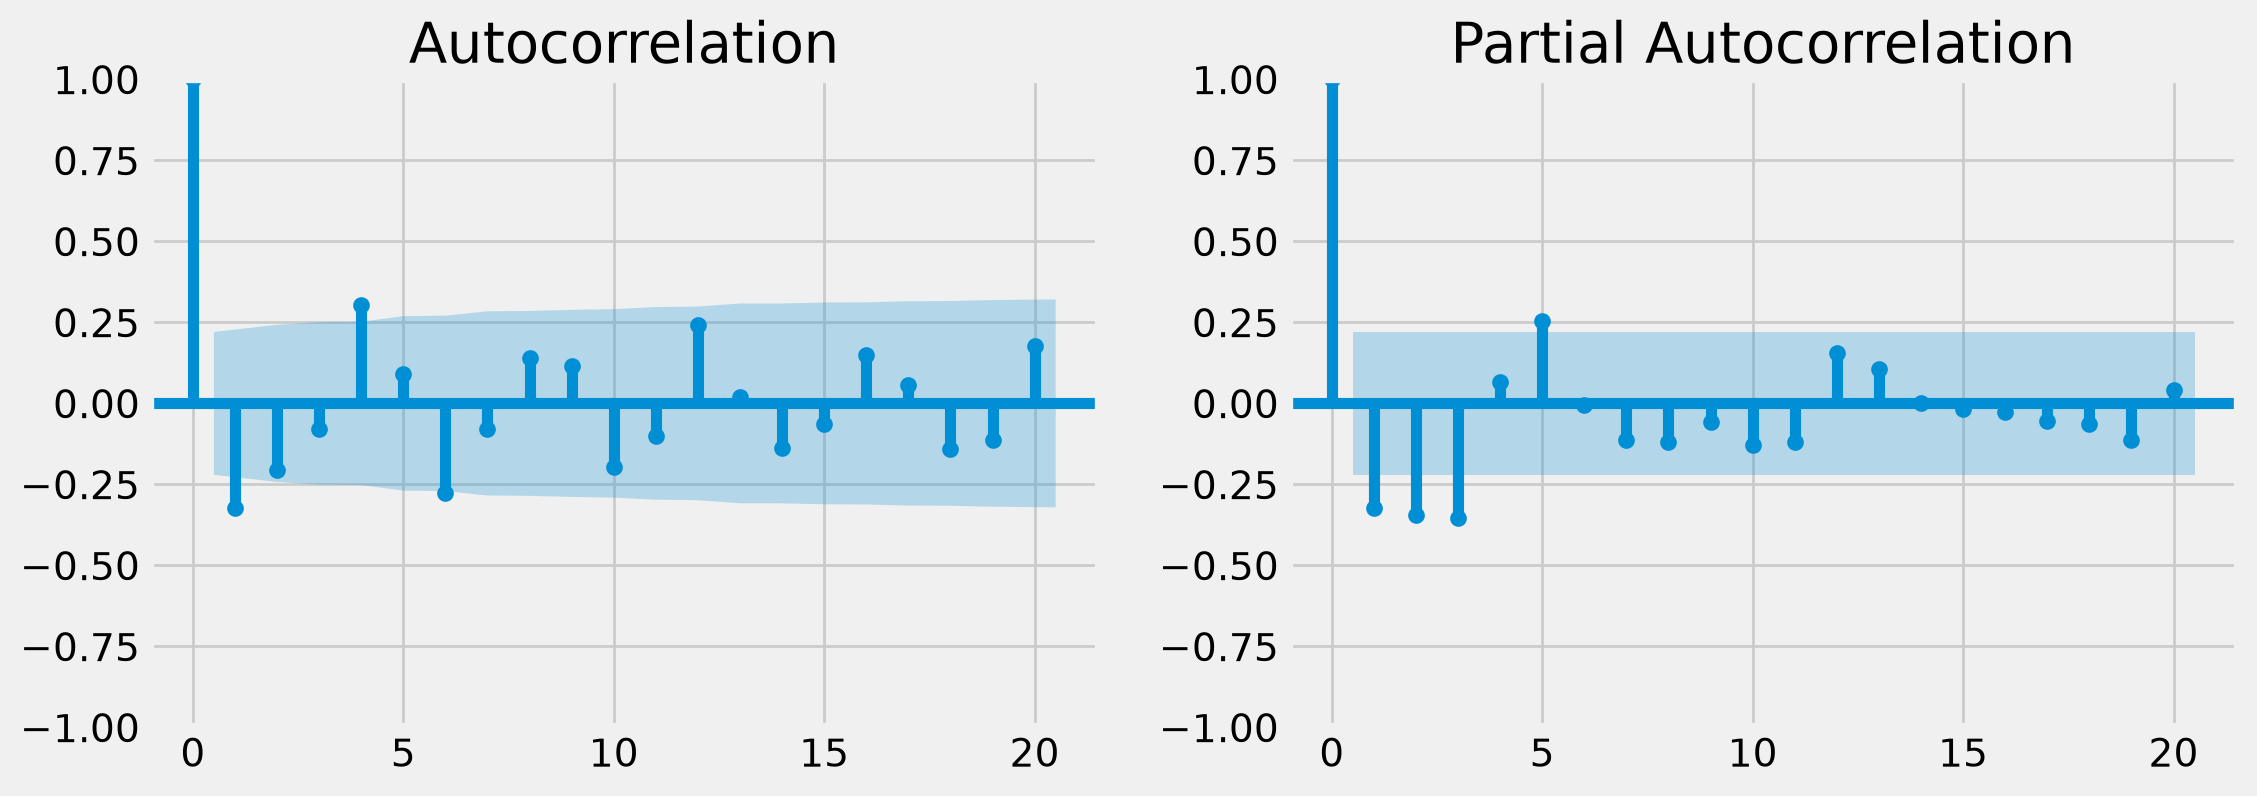

In [17]:
# YOUR CODE HERE
fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
plot_acf(df_eda['residents'].diff().diff().dropna(), lags=20, ax=ax[0])
plot_pacf(df_eda['residents'].diff().diff().dropna(), lags=20, ax=ax[1])
plt.show()

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

_The strongest spike shows up at lag 4, which lines up with the 4-quarter (1-year) seasonal cycle in this quarterly data, confirming the seasonality we saw in the decomposition._